# Environment Setup and Reproducibility

In this step, we import the libraries needed for the project, including TensorFlow, NumPy, OpenCV, Matplotlib, Seaborn, and Scikit-learn.

We also set a fixed random seed (`SEED = 42`) to make the results more reproducible. The seed is applied to Python, NumPy, and TensorFlow.

Finally, we check the TensorFlow version and whether a GPU is available in Google Colab.



In [ ]:
from google.colab import files
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Dataset Download and Setup

In this step, we upload the `kaggle.json` file and use it to access Kaggle from Google Colab.

The **Tennis Player Actions Dataset** is then downloaded from Kaggle and extracted into the `dataset` folder.



In [36]:
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d orvile/tennis-player-actions-dataset
!unzip -q tennis-player-actions-dataset.zip -d dataset

Saving kaggle.json to kaggle (2).json
Dataset URL: https://www.kaggle.com/datasets/orvile/tennis-player-actions-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
tennis-player-actions-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
replace dataset/Tennis Player Actions Dataset for Human Pose Estimation/annotations/backhand.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


# Dataset Structure Inspection

In this step, we check the contents of the `dataset` folder and display its folder structure.

This helps us make sure that the dataset was downloaded and extracted correctly before working with the images.



In [37]:
print("Contents of the dataset folder:")
print(os.listdir('dataset'))

print("\nFull directory structure:")
for root, dirs, files in os.walk('dataset'):
    if dirs:
        print(f"Folder: {root} contains the following subfolders: {dirs}")

Contents of the dataset folder:
['Tennis Player Actions Dataset for Human Pose Estimation']

Full directory structure:
Folder: dataset contains the following subfolders: ['Tennis Player Actions Dataset for Human Pose Estimation']
Folder: dataset/Tennis Player Actions Dataset for Human Pose Estimation contains the following subfolders: ['annotations', 'images']
Folder: dataset/Tennis Player Actions Dataset for Human Pose Estimation/images contains the following subfolders: ['backhand', 'ready_position', 'forehand', 'serve']


# Class Verification and Image Count

The dataset contains four classes: **backhand, forehand, ready position, and serve**.

In this step, we check that each class folder exists and count the number of images in each folder. This makes sure that all the expected classes are available before training the model.



In [23]:
DATASET_DIR = "dataset/Tennis Player Actions Dataset for Human Pose Estimation/images"
CLASS_NAMES = ["backhand", "forehand", "ready_position", "serve"]

for c in CLASS_NAMES:
    class_path = os.path.join(DATASET_DIR, c)
    exists = os.path.isdir(class_path)
    n_images = len(os.listdir(class_path)) if exists else 0
    print(f"{c:15s} | folder exists: {exists} | images: {n_images}")

backhand        | folder exists: True | images: 500
forehand        | folder exists: True | images: 500
ready_position  | folder exists: True | images: 500
serve           | folder exists: True | images: 500


# Visualizing Sample Images

In this step, we display one sample image from each class to check the dataset visually.

The images are converted from **BGR to RGB** before displaying them with Matplotlib.

This helps us make sure that the images are loaded correctly and that each class contains the expected tennis action.


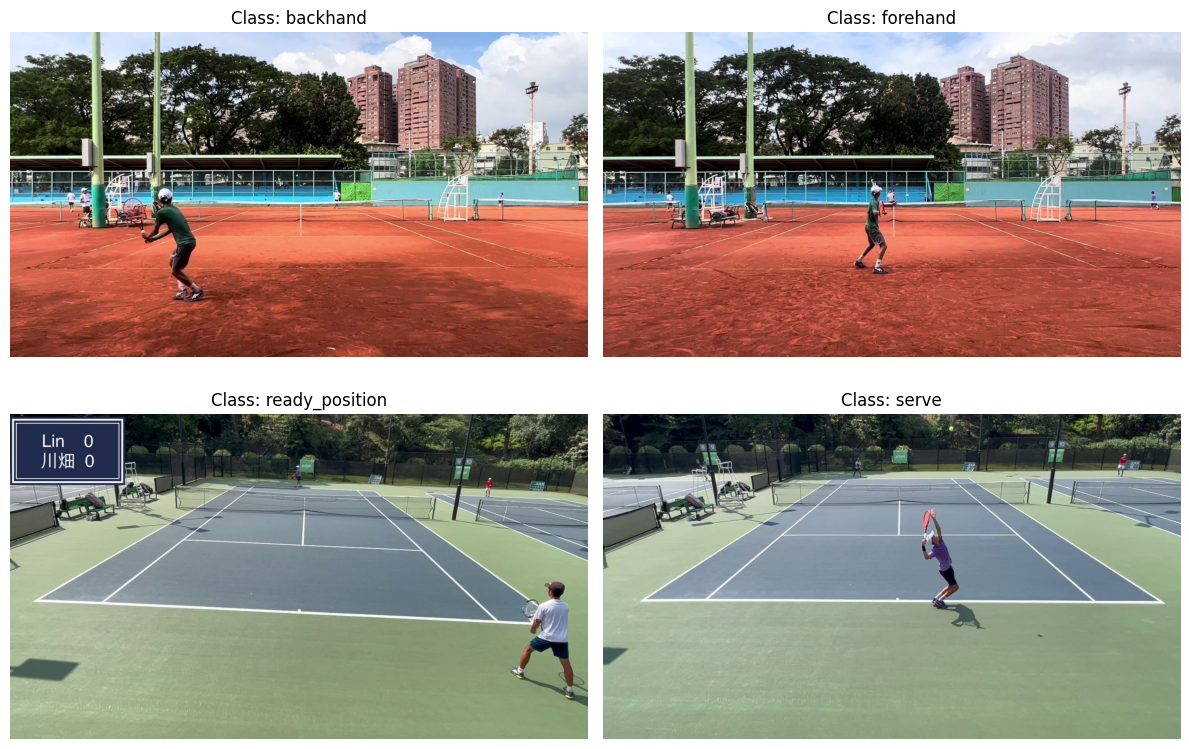

In [24]:
plt.figure(figsize=(12, 8))

for i, class_name in enumerate(CLASS_NAMES):
    class_dir = os.path.join(DATASET_DIR, class_name)
    image_name = os.listdir(class_dir)[0]
    image_path = os.path.join(class_dir, image_name)

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title(f"Class: {class_name}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Checking Image Properties

In this step, we load one sample image and check its basic properties.

We print the **image shape** to see its height, width, and number of color channels. We also print the **data type** of the image pixels.

This helps us understand the image format before starting the preprocessing steps.


In [25]:
sample_path = os.path.join(DATASET_DIR, "serve", os.listdir(os.path.join(DATASET_DIR, "serve"))[0])

img = cv2.imread(sample_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print("Image Shape:", img.shape)
print("Data Type:", img.dtype)

Image Shape: (720, 1280, 3)
Data Type: uint8


# RGB and Grayscale Comparison

In this step, we convert the sample image from **RGB to grayscale** and display both versions side by side.



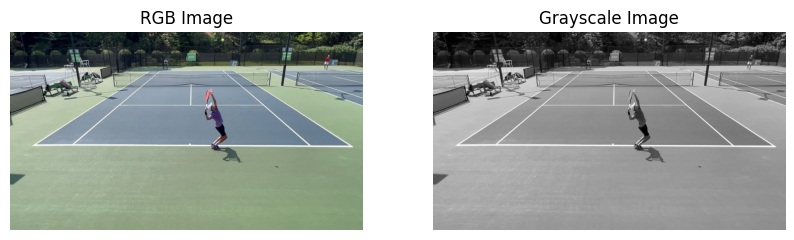

In [26]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(10,12))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("RGB Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.show()

# Loading and Splitting the Dataset

In this step, we load the images using `image_dataset_from_directory` and resize them to **150 × 150** pixels.

The dataset is split into **80% training** and **20% validation** using `validation_split=0.2`. A fixed seed is used to keep the split consistent.

The batch size is set to **32**, meaning the model processes 32 images at a time.

Finally, `cache()` and `prefetch()` are used to make the data loading faster during training.


In [27]:
DATASET_DIR = "dataset/Tennis Player Actions Dataset for Human Pose Estimation/images"
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("\nClass Names:", class_names)


# TO BE FASTER
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(buffer_size=1000, seed=SEED).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 2000 files belonging to 4 classes.
Using 1600 files for training.
Found 2000 files belonging to 4 classes.
Using 400 files for validation.

Class Names: ['backhand', 'forehand', 'ready_position', 'serve']


# Building the CNN Model

In this step, we build a **Convolutional Neural Network (CNN)** to classify the four tennis actions.

The model first scales the pixel values from **0–255 to 0–1**, then uses convolution and pooling layers to learn features from the images.

After that, the features are flattened and passed through a dense layer. **Dropout** is used to help reduce overfitting.

The final **Softmax** layer produces the probability for each of the four classes.

Finally, `model.summary()` displays the model architecture and the number of parameters.


In [29]:
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(150, 150, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(CLASS_NAMES), activation='softmax')
])

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_5 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 70, 70, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 35, 35, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 156800)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    20,070,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,164,292 (76.92 MB)

 Trainable params: 20,164,292 (76.92 MB)

 Non-trainable params: 0 (0.00 B)

# Compiling and Training the Model

In this step, we compile the CNN using the **Adam** optimizer and **Sparse Categorical Crossentropy** loss.

The model is trained for up to **50 epochs**. `EarlyStopping` monitors the validation loss and stops training if it does not improve for **3 epochs**. The best model weights are then restored.

Finally, the trained model is saved as `tennis_model.keras` inside the `saved_model` folder.


In [30]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop]
)


os.makedirs("saved_model", exist_ok=True)
model.save("saved_model/tennis_model.keras")
print("\nModel saved successfully at saved_model/tennis_model.keras")

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 88ms/step - accuracy: 0.4050 - loss: 1.6877 - val_accuracy: 0.5075 - val_loss: 1.0872
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.6000 - loss: 0.9516 - val_accuracy: 0.6325 - val_loss: 0.8210
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.7031 - loss: 0.7142 - val_accuracy: 0.7300 - val_loss: 0.6636
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.7581 - loss: 0.5947 - val_accuracy: 0.7750 - val_loss: 0.6026
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.7962 - loss: 0.5049 - val_accuracy: 0.7750 - val_loss: 0.5855
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.8325 - loss: 0.4265 - val_accuracy: 0.7925 - val_loss: 0.5995
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.8556 - loss: 0.3615 - val_accuracy: 0.8100 - val_loss: 0.5493
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.8781 - loss: 0.3098 - val_accuracy: 0.8300 - 

# 11. Training Performance Visualization

In this step, we plot the **training and validation accuracy and loss** for each epoch.

The accuracy plot shows how well the model performs during training and validation, while the loss plot shows how the model's error changes over time.

These plots help us understand the model's learning progress and check for possible **overfitting or underfitting**.


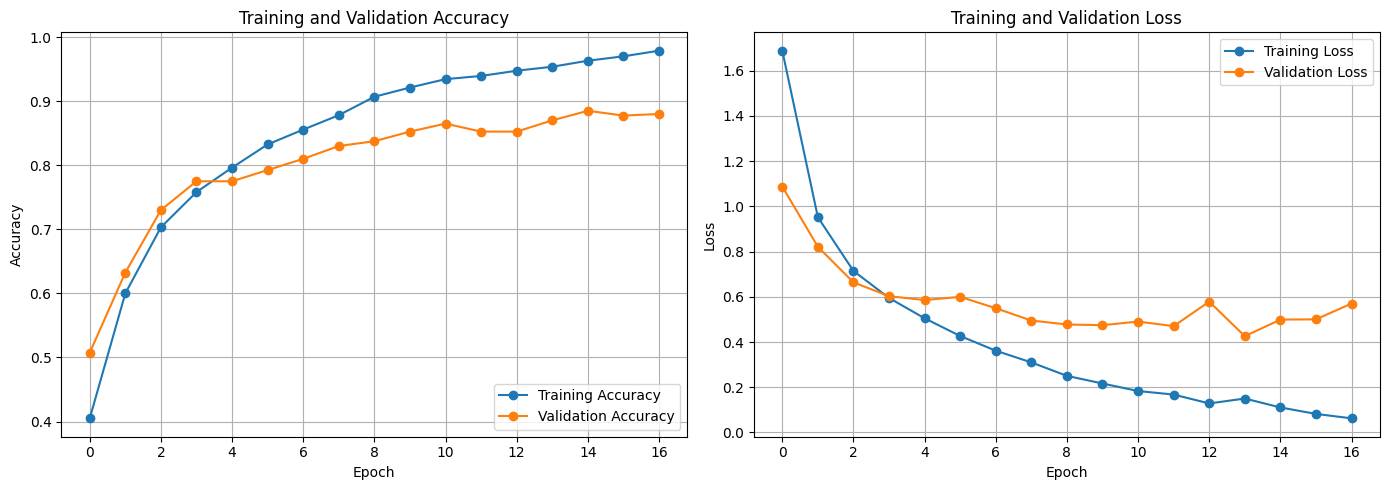

In [31]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, marker='o', label='Training Accuracy')
plt.plot(epochs_range, val_acc, marker='o', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, marker='o', label='Training Loss')
plt.plot(epochs_range, val_loss, marker='o', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

## 12. Model Evaluation

In this step, we evaluate the trained model on the validation dataset.

The **confusion matrix** shows how many images from each class were correctly or incorrectly classified.

The **classification report** provides the main evaluation metrics for each class, including **precision, recall, and F1-score**.

These results help us understand how well the model performs on each tennis action.


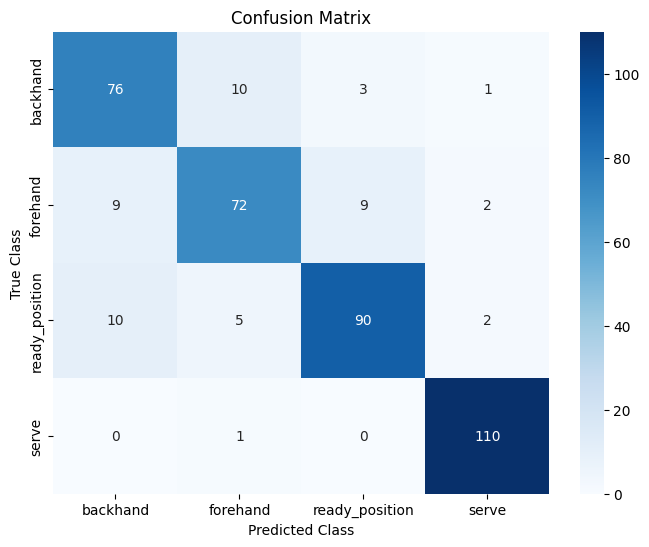


Classification Report:

                precision    recall  f1-score   support

      backhand       0.80      0.84      0.82        90
      forehand       0.82      0.78      0.80        92
ready_position       0.88      0.84      0.86       107
         serve       0.96      0.99      0.97       111

      accuracy                           0.87       400
     macro avg       0.86      0.86      0.86       400
  weighted avg       0.87      0.87      0.87       400



In [32]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))


cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap='Blues')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix')
plt.show()


print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# 13. Testing the Model on a Single Image

In this step, we create a function to test the trained model on a single image.

The image is loaded, converted to RGB, resized to **150 × 150**, and passed to the model for prediction.

The function then displays the image with the **predicted class** and the model's **confidence score**.

Finally, we test the function using a sample image from the **serve** class.


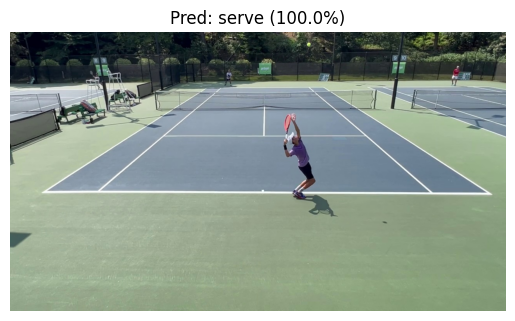

In [38]:
def predict_image(image_path):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    resized_img = cv2.resize(img_rgb, (150, 150))
    input_tensor = np.expand_dims(resized_img, axis=0)

    predictions = model.predict(input_tensor, verbose=0)
    score = tf.nn.softmax(predictions[0])
    predicted_class = CLASS_NAMES[np.argmax(predictions)]
    confidence = np.max(predictions) * 100

    plt.imshow(img_rgb)
    plt.title(f"Pred: {predicted_class} ({confidence:.1f}%)")
    plt.axis('off')
    plt.show()

sample_test_img = os.path.join(DATASET_DIR, "serve", os.listdir(os.path.join(DATASET_DIR, "serve"))[0])
predict_image(sample_test_img)